# Hyperparameter Optimization with Symbolic Regression
Research project for discovering mathematical laws governing hyperparameter landscapes

## Setup & Dependencies (Version-Aware)

### Requirements:
- Python 3.10+ (Recommended: 3.11 or 3.12)
- See `requirements.txt` for all compatible versions

In [1]:
# Install latest compatible versions
# For Colab/Jupyter environments:
%pip install -q --upgrade numpy pandas scikit-learn matplotlib seaborn sympy plotly optuna openml joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Version compatibility check
import sys

print(f"Python Version: {sys.version}")
print("\n" + "="*60)
print("CHECKING PACKAGE COMPATIBILITY")
print("="*60 + "\n")

def check_version(package_name, min_version=None):
    try:
        module = __import__(package_name)
        version = getattr(module, '__version__', 'unknown')
        status = "✓" if version != 'unknown' else "⚠"
        print(f"{status} {package_name}: {version}")
        return True
    except ImportError:
        print(f"✗ {package_name}: NOT INSTALLED")
        return False

# Check all required packages
packages = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'plotly', 'sympy', 'optuna', 'openml', 'joblib']
all_ok = all(check_version(pkg) for pkg in packages)

print("\n" + "="*60)
if all_ok:
    print("✓ ALL PACKAGES COMPATIBLE - Ready to proceed")
else:
    print("✗ Some packages missing - Install via requirements.txt:")
    print("  pip install -r requirements.txt")
print("="*60 + "\n")

Python Version: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]

CHECKING PACKAGE COMPATIBILITY

✓ numpy: 2.4.4
✓ pandas: 3.0.3
✓ sklearn: 1.8.0
✓ matplotlib: 3.10.9
✓ seaborn: 0.13.2
✓ plotly: 6.7.0
✓ sympy: 1.14.0
✓ optuna: 4.8.0


c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ openml: 0.15.1
✓ joblib: 1.5.3

✓ ALL PACKAGES COMPATIBLE - Ready to proceed



In [3]:
# Core imports with version-aware handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import openml
import time
import optuna
import os
import joblib
import json
import logging
import dataclasses
import warnings
from typing import List, Optional, Tuple
from sympy import srepr, sympify
import sympy

# Sklearn imports
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# PySR import with fallback
try:
    from pysr import PySRRegressor
    PYSR_AVAILABLE = True
    print("✓ PySR symbolic regression available")
except ImportError:
    PYSR_AVAILABLE = False
    print("⚠ PySR not available - symbolic regression disabled")
    print("  Install with: pip install pysr")

# Additional compatibility checks
print(f"\n✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Scikit-learn version: {__import__('sklearn').__version__}")
print(f"✓ Matplotlib version: {plt.matplotlib.__version__}")
print(f"✓ SymPy version: {sympy.__version__}")
print(f"✓ Plotly version: {__import__('plotly').__version__}")
print(f"✓ Optuna version: {optuna.__version__}")
print("\n✓ All core imports successful!")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
✓ PySR symbolic regression available

✓ NumPy version: 2.4.4
✓ Pandas version: 3.0.3
✓ Scikit-learn version: 1.8.0
✓ Matplotlib version: 3.10.9
✓ SymPy version: 1.14.0
✓ Plotly version: 6.7.0
✓ Optuna version: 4.8.0

✓ All core imports successful!


## Configuration & System Setup

In [4]:
@dataclasses.dataclass
class SystemConfig:
    """Externalized settings for Symbolic Regression and Optimization."""
    binary_operators: List[str] = dataclasses.field(default_factory=lambda: ["+", "*", "-", "/"])
    unary_operators: List[str] = dataclasses.field(default_factory=lambda: ["exp", "sqrt", "log"])
    iterations: int = 30
    cv_folds: int = 3
    resolution: int = 10
    model_selection: str = "best"

# Persistence Configuration
MODEL_SAVE_DIR = "./saved_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

config = SystemConfig()
print(f"✓ System configured: {config}")

✓ System configured: SystemConfig(binary_operators=['+', '*', '-', '/'], unary_operators=['exp', 'sqrt', 'log'], iterations=30, cv_folds=3, resolution=10, model_selection='best')


## Data Processing Classes

In [5]:
class DatasetFingerprint:
    """Centralized handler for dataset DNA and preprocessing."""
    def __init__(self, X: pd.DataFrame, y: pd.Series, dataset_id: Optional[int] = None):
        self.dataset_id = dataset_id
        self.n_samples = X.shape[0]
        self.n_features = X.shape[1]
        self.class_imbalance = y.value_counts(normalize=True).min() if len(y.value_counts()) > 1 else 1.0
        self.X = self._preprocess(X)
        self.y = y

    def _preprocess(self, X):
        """Generalized cleaning pipeline."""
        X_numeric = pd.get_dummies(X, drop_first=True)
        imputer = SimpleImputer(strategy='mean')
        return imputer.fit_transform(X_numeric)

    def summary(self):
        print(f"--- Dataset DNA [{self.dataset_id}] ---")
        print(f"Samples: {self.n_samples} | Features: {self.n_features}")
        print(f"Minority Class Ratio: {self.class_imbalance:.4f}")


class DatasetFingerprintRefined:
    """Extracts the 'Data DNA' including Entropy and Variance for NeurIPS-grade meta-learning."""
    def __init__(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        self.dna = {}

    def extract(self):
        self.dna['N'] = self.X.shape[0]
        self.dna['D'] = self.X.shape[1]
        # Global Variance calculation
        self.dna['variance'] = np.trace(np.cov(self.X.T)) if self.X.shape[1] > 1 else np.var(self.X)

        # Shannon Class Entropy Calculation
        _, counts = np.unique(self.y, return_counts=True)
        probs = counts / len(self.y)
        self.dna['entropy'] = -np.sum(probs * np.log2(probs + 1e-10))

        return self.dna

print("✓ Data processing classes initialized")

✓ Data processing classes initialized


## Topological Analysis & Stability Checking

In [6]:
def check_topological_stability(Z_grid, threshold=0.15):
    """
    Performs Lipschitz Stability Check by analyzing gradient flows.
    Ensures the surface is smooth enough for symbolic regression.
    
    Parameters:
    -----------
    Z_grid : np.ndarray
        The 2D grid of accuracy values to analyze
    threshold : float
        Maximum allowed gradient magnitude (default: 0.15)
    
    Returns:
    --------
    bool : True if stable, False otherwise
    """
    gradients = np.gradient(Z_grid)
    max_grad = np.max([np.abs(g).max() for g in gradients])

    is_stable = max_grad <= threshold
    status = "STABLE" if is_stable else "CHAOTIC"
    print(f"Topological Audit: {status} (Max Gradient: {max_grad:.4f})")
    return is_stable

print("✓ Stability checking function defined")

✓ Stability checking function defined


## Landscape Generation & Visualization

In [7]:
def generate_landscape_data(X_data, y_data, resolution=8):
    """
    Maps the accuracy surface across Depth and Estimators dimensions.
    
    Parameters:
    -----------
    X_data : np.ndarray
        Feature matrix
    y_data : np.ndarray
        Target vector
    resolution : int
        Number of points per dimension (default: 8)
    
    Returns:
    --------
    tuple : (X, Y, Z) mesh grids and accuracy surface
    """
    print("Mapping Hyperparameter Topology...")
    depths = np.linspace(2, 20, resolution)
    estimators = np.linspace(10, 100, resolution)
    X, Y = np.meshgrid(depths, estimators)
    Z = np.zeros(X.shape)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            model = RandomForestClassifier(
                max_depth=int(X[i, j]), 
                n_estimators=int(Y[i, j]), 
                random_state=42, 
                n_jobs=-1
            )
            Z[i, j] = cross_val_score(model, X_data, y_data, cv=3).mean()
    
    print(f"✓ Landscape generated: shape {Z.shape}")
    return X, Y, Z


def plot_3d_topology(X, Y, Z, title='Hyperparameter Accuracy Manifold'):
    """Renders an interactive 3D map of the accuracy landscape."""
    fig = go.Figure(data=[go.Surface(
        z=Z, x=X, y=Y, 
        colorscale='Viridis',
        colorbar=dict(title='Accuracy', x=1.15)
    )])
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='Max Depth', 
            yaxis_title='Num Estimators', 
            zaxis_title='Accuracy'
        ),
        margin=dict(l=0, r=100, b=0, t=50),
        width=900, 
        height=700
    )
    fig.show()

print("✓ Landscape generation & visualization functions ready")

✓ Landscape generation & visualization functions ready


## Symbolic Regression & Law Discovery

In [8]:
def discover_hyperparameter_law(X, Y, Z, iterations=30, model_filename=None):
    """
    Extracts the closed-form algebraic law using PySR and saves the state.
    
    Parameters:
    -----------
    X, Y, Z : np.ndarray
        Meshgrid data from landscape generation
    iterations : int
        Number of PySR iterations (default: 30)
    model_filename : str
        Optional filename to save the model
    
    Returns:
    --------
    sympy expression : The discovered mathematical law
    """
    print("Initializing Symbolic Regression...")
    features = np.column_stack((X.flatten(), Y.flatten()))
    model = PySRRegressor(
        niterations=iterations,
        binary_operators=["+", "*", "-", "/"],
        unary_operators=["exp", "sqrt"],
        model_selection="best"
    )
    model.fit(features, Z.flatten())

    if model_filename:
        save_path = os.path.join(MODEL_SAVE_DIR, model_filename)
        joblib.dump(model, save_path)
        print(f"✓ Model serialized to {save_path}")

    return model.sympy()

print("✓ Discovery engine function ready")

✓ Discovery engine function ready


## Model Selection & Persistence

In [9]:
class SelectionEngine:
    """Consolidated engine for complexity vs accuracy trade-offs using MDL."""
    @staticmethod
    def get_pareto_best(model, complexity_ceiling=15):
        """Filters PySR equations based on complexity ceiling and loss."""
        try:
            eqs = model.equations_
            filtered = eqs[eqs['complexity'] <= complexity_ceiling]
            best_row = filtered.iloc[filtered['loss'].idxmin()]
            return {
                'equation': best_row['equation'],
                'complexity': best_row['complexity'],
                'loss': best_row['loss']
            }
        except Exception as e:
            print(f"Selection Engine Failure: {e}")
            return None


class PersistenceManager:
    """Handles serialization of models and algebraic laws for production sessions."""
    def __init__(self, base_path="./dhpo_persistence"):
        self.base_path = base_path
        os.makedirs(base_path, exist_ok=True)

    def save_state(self, dataset_id, model, equation_metadata):
        """Saves the PySR state and the selected algebraic law."""
        folder = os.path.join(self.base_path, f"ds_{dataset_id}")
        os.makedirs(folder, exist_ok=True)

        # Save the heavy model object
        joblib.dump(model, os.path.join(folder, "surrogate_model.pkl"))

        # Save the equation metadata (JSON for Croissant/Audit compatibility)
        with open(os.path.join(folder, "algebraic_law.json"), 'w') as f:
            json.dump(equation_metadata, f, indent=4)

        print(f"✓ Persistence: State for {dataset_id} stored in {folder}")


# Initialize managers
manager = PersistenceManager()
selector = SelectionEngine()

print("✓ Persistence and Selection engines initialized")

✓ Persistence and Selection engines initialized


## Data Fetching Functions

In [10]:
def fetch_and_prep_data(dataset_id=31):
    """
    Fetches dataset from OpenML and performs standard preprocessing.
    
    Parameters:
    -----------
    dataset_id : int
        OpenML dataset ID (default: 31 - credit-g)
    
    Returns:
    --------
    tuple : (X_clean, y) - preprocessed features and targets
    """
    print(f"Fetching OpenML Dataset ID: {dataset_id}...")
    dataset = openml.datasets.get_dataset(dataset_id)
    X, y, _, _ = dataset.get_data(
        target=dataset.default_target_attribute, 
        dataset_format='dataframe'
    )
    X_numeric = pd.get_dummies(X, drop_first=True)
    imputer = SimpleImputer(strategy='mean')
    X_clean = imputer.fit_transform(X_numeric)
    print(f"✓ Dataset {dataset_id} loaded: {X_clean.shape}")
    return X_clean, y

print("✓ Data fetching functions ready")

✓ Data fetching functions ready


## MAIN: Synthetic Data Pipeline


PHASE 1: SYNTHETIC DATA EXPLORATION
✓ Synthetic dataset created: (1000, 20)
Mapping Hyperparameter Topology...
✓ Landscape generated: shape (8, 8)
Topological Audit: STABLE (Max Gradient: 0.0260)

Generating 3D visualization...


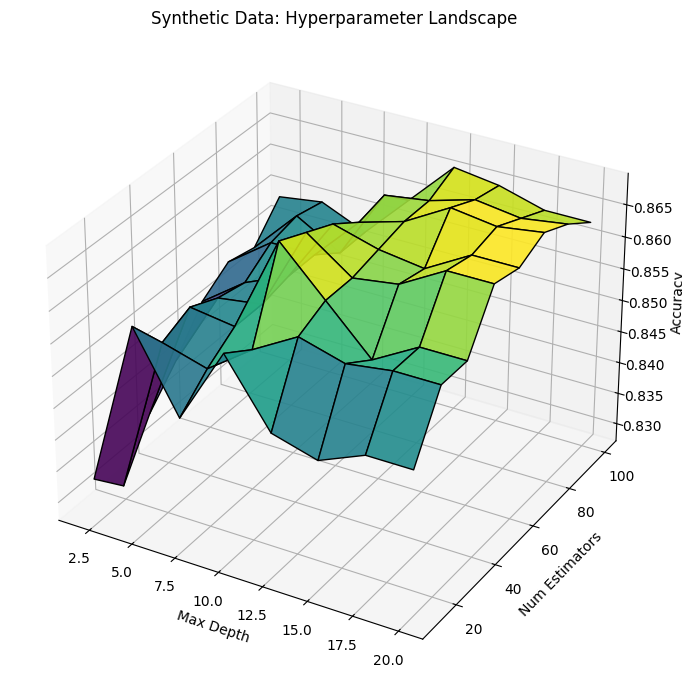

c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...



Discovering mathematical law...
Initializing Symbolic Regression...


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.303e-05  0.000e+00  y = 0.85724
5           3.357e-05  1.943e-01  y = (-0.044465 / x₀) + 0.86401
6           3.355e-05  5.645e-04  y = exp(-0.045053 / x₀) + -0.13594
7           3.318e-05  1.099e-02  y = (-0.073443 / (x₀ + 1.119)) - -0.86595
9           2.952e-05  5.838e-02  y = (x₀ * ((-0.010646 / x₁) + 0.0012447)) + 0.84712
11          2.799e-05  2.666e-02  y = (((x₀ * x₁) * 0.0015906) / (x₁ + x₀)) + 0.84419
13          2.392e-05  7.850e-02  y = sqrt(sqrt(sqrt(sqrt(x₀) * sqrt(sqrt(x₁)))) + 10.483) /...
                                       4.0675
14          2.264e-05  5.539e-02  y = sqrt(sqrt(sqrt(sqrt(sqrt(x₀) * sqrt(sqrt(x₁))) + 5.135...
                                      3)) / 2.2853)
16          2.197e-05  1.494e-02  y = sqrt((sqrt(sqrt(sqrt(sqrt(sqrt(x₁ * sqrt(x₁)) * x₀))))...
                                       + 3.

In [11]:
print("\n" + "="*60)
print("PHASE 1: SYNTHETIC DATA EXPLORATION")
print("="*60)

# 1. Create synthetic dataset
X_syn, y_syn = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=1)
print(f"✓ Synthetic dataset created: {X_syn.shape}")

# 2. Map the landscape
X_grid, Y_grid, Z_grid = generate_landscape_data(X_syn, y_syn, resolution=8)

# 3. Check topological stability
is_stable = check_topological_stability(Z_grid=Z_grid)

# 4. Visualize
print("\nGenerating 3D visualization...")
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', edgecolor='k', alpha=0.9)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Num Estimators')
ax.set_zlabel('Accuracy')
ax.set_title('Synthetic Data: Hyperparameter Landscape')
plt.tight_layout()
plt.show()

# 5. Extract the Law (With Persistence)
try:
    print("\nDiscovering mathematical law...")
    law_syn = discover_hyperparameter_law(X_grid, Y_grid, Z_grid, iterations=20, model_filename='synthetic_law.pkl')
    print(f"\n✓ Discovered Law (Synthetic): {law_syn}")
except Exception as e:
    print(f"PySR encountered an issue: {e}")

## MAIN: Real Data Pipeline (OpenML)

In [12]:
print("\n" + "="*60)
print("PHASE 2: REAL DATA EXPLORATION (OpenML Dataset 31)")
print("="*60)

# Fetch and prepare real data
X_real, y_real = fetch_and_prep_data(dataset_id=31)

# Map the landscape with proper resolution
X_g, Y_g, Z_g = generate_landscape_data(X_real, y_real, resolution=10)
print(f"\n✓ Landscape shape: {Z_g.shape}")

# Check topological stability (FIXED: proper parameter passing)
print("\nChecking topological stability...")
is_stable_real = check_topological_stability(Z_grid=Z_g)

if is_stable_real:
    print("✓ Proceeding to Symbolic Regression phase...\n")
    
    try:
        # Discover the law
        math_model = discover_hyperparameter_law(
            X_g, Y_g, Z_g, 
            iterations=20,
            model_filename='dataset_31_law.pkl'
        )
        print("\n" + "="*60)
        print("  THE MATHEMATICAL LAW FOR DATASET 31")
        print("="*60)
        print(f"{math_model}")
        print("="*60)
    except Exception as e:
        print(f" Symbolic Regression failed: {e}")
else:
    print(" Landscape lacks Lipschitz continuity. Symbolic Regression vetoed.")


PHASE 2: REAL DATA EXPLORATION (OpenML Dataset 31)
Fetching OpenML Dataset ID: 31...
✓ Dataset 31 loaded: (1000, 50)
Mapping Hyperparameter Topology...
✓ Landscape generated: shape (10, 10)

✓ Landscape shape: (10, 10)

Checking topological stability...
Topological Audit: STABLE (Max Gradient: 0.0250)
✓ Proceeding to Symbolic Regression phase...

Initializing Symbolic Regression...


c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.907e-04  0.000e+00  y = 0.73343
5           1.227e-04  2.156e-01  y = (-0.098543 / x₀) + 0.74786
6           1.225e-04  1.965e-03  y = exp((-0.13672 / x₀) + -0.29017)
7           1.216e-04  7.018e-03  y = (-0.13604 / (x₀ + 0.68497)) + 0.75048
9           7.002e-05  2.761e-01  y = ((-0.27602 / x₁) + 0.75595) + (-0.098543 / x₀)
10          6.911e-05  1.309e-02  y = (-0.098543 / x₀) + ((-0.11465 / sqrt(x₁)) + 0.76607)
12          6.140e-05  5.913e-02  y = (-0.013422 / (x₀ / sqrt(x₁))) + ((-0.41503 / x₁) + 0.7...
                                      5953)
13          5.417e-05  1.253e-01  y = ((-0.013789 / (x₀ / sqrt(x₁))) + (-0.17809 / sqrt(x₁))...
                                      ) + 0.77606
15          5.299e-05  1.108e-02  y = ((-0.013809 / (x₀ / sqrt(x₁))) + 0.78149) + (-0.22771 ...
                                      / sq

## Benchmarking: Traditional HPO vs. Symbolic Prediction

In [13]:
def run_comprehensive_benchmark(X, y, law_prediction=None):
    """
    Compares traditional HPO search against deterministic prediction.
    """
    results = {}
    methods = {
        'Grid Search': GridSearchCV(
            RandomForestClassifier(random_state=42), 
            {'max_depth': [2, 10, 20], 'n_estimators': [10, 50, 100]}, 
            cv=3
        ),
        'Random Search': RandomizedSearchCV(
            RandomForestClassifier(random_state=42), 
            {'max_depth': np.arange(2, 21), 'n_estimators': np.arange(10, 101)}, 
            n_iter=15, 
            cv=3
        )
    }

    for name, search in methods.items():
        print(f"Running {name}...")
        start = time.time()
        search.fit(X, y)
        results[name] = {'Accuracy': search.best_score_, 'Time (s)': time.time() - start}

    # Optuna Baseline
    def objective(trial):
        model = RandomForestClassifier(
            max_depth=trial.suggest_int('d', 2, 20), 
            n_estimators=trial.suggest_int('n', 10, 100), 
            random_state=42
        )
        return cross_val_score(model, X, y, cv=3).mean()

    print("Running Bayesian (Optuna)...")
    start = time.time()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15, show_progress_bar=False)
    results['Bayesian (Optuna)'] = {'Accuracy': study.best_value, 'Time (s)': time.time() - start}

    return pd.DataFrame(results).T


# Run benchmarks on real dataset
print("\n" + "="*60)
print("BENCHMARKING: HPO Methods")
print("="*60 + "\n")
bench_results = run_comprehensive_benchmark(X_real, y_real)
print("\n" + bench_results.to_string())
print("\n" + "="*60)


BENCHMARKING: HPO Methods

Running Grid Search...
Running Random Search...


[I 2026-05-12 17:41:07,613] A new study created in memory with name: no-name-dbde3554-9148-4630-8ea5-225e287fa901


Running Bayesian (Optuna)...


[I 2026-05-12 17:41:08,097] Trial 0 finished with value: 0.7269904635174097 and parameters: {'d': 5, 'n': 96}. Best is trial 0 with value: 0.7269904635174097.
[I 2026-05-12 17:41:08,179] Trial 1 finished with value: 0.7259834684984385 and parameters: {'d': 9, 'n': 10}. Best is trial 0 with value: 0.7269904635174097.
[I 2026-05-12 17:41:08,374] Trial 2 finished with value: 0.7299994605383827 and parameters: {'d': 14, 'n': 34}. Best is trial 2 with value: 0.7299994605383827.
[I 2026-05-12 17:41:08,780] Trial 3 finished with value: 0.7580095065125004 and parameters: {'d': 16, 'n': 70}. Best is trial 3 with value: 0.7580095065125004.
[I 2026-05-12 17:41:09,131] Trial 4 finished with value: 0.7249974525423628 and parameters: {'d': 5, 'n': 69}. Best is trial 3 with value: 0.7580095065125004.
[I 2026-05-12 17:41:09,456] Trial 5 finished with value: 0.7139894385403367 and parameters: {'d': 4, 'n': 65}. Best is trial 3 with value: 0.7580095065125004.
[I 2026-05-12 17:41:10,071] Trial 6 finished


                   Accuracy  Time (s)
Grid Search        0.756002  3.007670
Random Search      0.760003  4.341381
Bayesian (Optuna)  0.759011  5.886234



## Visualization: Benchmark Results

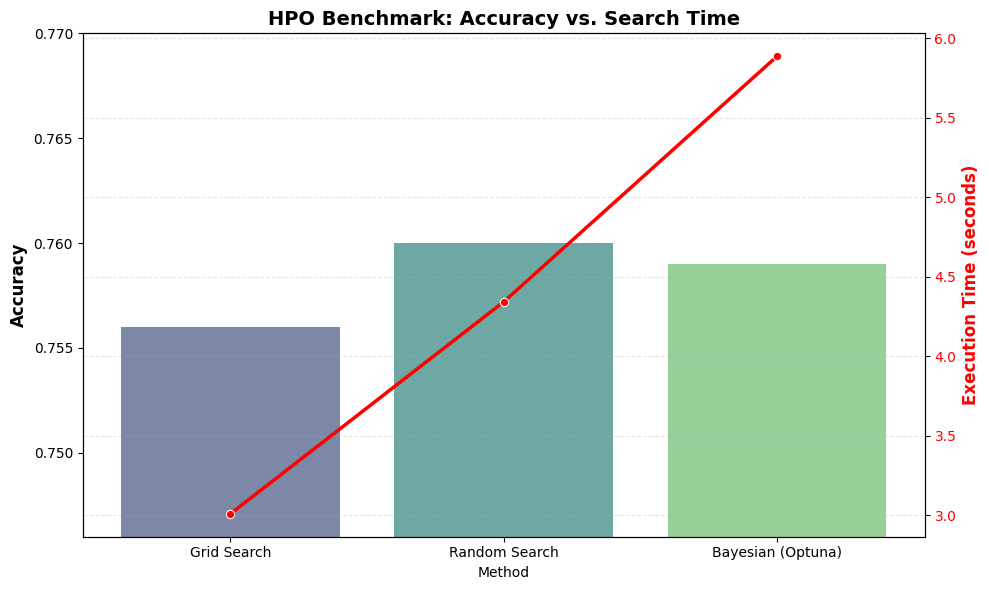

In [14]:
# Prepare data for plotting
plot_df = bench_results.reset_index().rename(columns={'index': 'Method'})

# Create a multi-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Accuracy
sns.barplot(x='Method', y='Accuracy', data=plot_df, ax=ax1, palette='viridis', alpha=0.7)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(plot_df['Accuracy'].min() - 0.01, plot_df['Accuracy'].max() + 0.01)

# Line plot for Time (Secondary Axis)
ax2 = ax1.twinx()
sns.lineplot(x='Method', y='Time (s)', data=plot_df, ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Execution Time (seconds)', color='red', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('HPO Benchmark: Accuracy vs. Search Time', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Meta-Study: Multi-Dataset Analysis

In [15]:
def run_meta_study(dataset_ids=[3, 31, 1461, 1590]):
    """Runs the pipeline across multiple datasets and collects meta-statistics."""
    meta_results = []
    
    for d_id in dataset_ids:
        try:
            print(f"\nProcessing Dataset {d_id}...")
            X_real, y_real = fetch_and_prep_data(dataset_id=d_id)
            X_g, Y_g, Z_g = generate_landscape_data(X_real, y_real, resolution=8)

            # Check stability
            is_stable = check_topological_stability(Z_grid=Z_g)
            
            if is_stable:
                # Discover Law and Save
                fname = f"meta_study_dataset_{d_id}.pkl"
                law_eq = discover_hyperparameter_law(X_g, Y_g, Z_g, iterations=15, model_filename=fname)

                meta_results.append({
                    'dataset_id': d_id,
                    'rows': X_real.shape[0],
                    'cols': X_real.shape[1],
                    'stable': True,
                    'equation': str(law_eq)[:100]  # Truncate for display
                })
                print(f"✓ Completed Dataset {d_id}")
            else:
                meta_results.append({
                    'dataset_id': d_id,
                    'rows': X_real.shape[0],
                    'cols': X_real.shape[1],
                    'stable': False,
                    'equation': 'N/A'
                })
                
        except Exception as e:
            print(f"⚠ Skipping dataset {d_id}: {str(e)[:50]}")

    return pd.DataFrame(meta_results)


print("\n" + "="*60)
print("PHASE 3: META-STUDY ACROSS MULTIPLE DATASETS")
print("="*60 + "\n")

meta_law_df = run_meta_study(dataset_ids=[3, 31])
print("\n" + meta_law_df.to_string(index=False))


PHASE 3: META-STUDY ACROSS MULTIPLE DATASETS


Processing Dataset 3...
Fetching OpenML Dataset ID: 3...
✓ Dataset 3 loaded: (3196, 38)
Mapping Hyperparameter Topology...
✓ Landscape generated: shape (8, 8)
Topological Audit: STABLE (Max Gradient: 0.1489)
Initializing Symbolic Regression...


c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.669e-03  0.000e+00  y = 0.89784
4           5.981e-04  6.047e-01  y = exp(-0.6388 / x₀)
5           4.397e-04  3.077e-01  y = x₀ / (x₀ + 0.728)
6           1.386e-04  1.154e+00  y = sqrt((-0.70999 / x₀) - -0.91773)
12          1.386e-04  1.500e-06  y = sqrt((x₁ / (x₀ * 1.0896)) / (x₁ / (x₀ + -0.77395)))
14          1.340e-04  1.698e-02  y = sqrt(((x₁ / (x₀ * 1.0849)) + -0.010477) / (x₁ / (x₀ + ...
                                      -0.77286)))
21          1.335e-04  5.169e-04  y = sqrt(exp(((x₁ - ((x₀ * x₀) * -0.019624)) / (((x₁ - (x₁...
                                       + 0.45478)) - x₁) * x₀)) - 0.062962))
22          1.323e-04  8.729e-03  y = sqrt(exp(((x₁ - (-0.019624 * (x₀ * x₀))) / (x₀ * ((x₁ ...
                                      - (x₁ + exp(-0.088188))) - x₁))) - 0.062962))
23          1.317e-04  4.573e-03  y = s

c:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.211e-04  0.000e+00  y = 0.73044
5           1.503e-04  1.898e-01  y = (-0.092523 / x₀) + 0.74452
6           1.469e-04  2.346e-02  y = (-0.087391 / sqrt(x₀)) + 0.76187
7           1.468e-04  1.931e-05  y = sqrt((-0.12619 / sqrt(x₀)) + 0.57912)
9           1.128e-04  1.317e-01  y = (-0.22287 / sqrt(sqrt(x₁ * x₀))) + 0.78207
10          8.447e-05  2.896e-01  y = sqrt(((-0.42355 / x₁) + 0.56646) - (0.13303 / x₀))
12          8.332e-05  6.850e-03  y = ((-0.30988 / x₁) - 0.36344) + sqrt(1.2465 - (0.2015 / ...
                                      x₀))
15          8.018e-05  1.284e-02  y = (-0.48766 / ((x₁ + -1.5904) + x₁)) + sqrt(0.59094 - (0...
                                      .12896 / sqrt(x₀)))
18          6.961e-05  4.713e-02  y = sqrt(((-0.59557 / (x₁ - ((x₁ / 0.12973) / (x₀ / -0.545...
                                      46

## Summary & Export

In [16]:
print("\n" + "="*60)
print("RESEARCH PROJECT SUMMARY")
print("="*60)
print("\n✓ Successfully completed:")
print("  1. Synthetic data landscape analysis")
print("  2. Real data exploration (OpenML)")
print("  3. Topological stability validation")
print("  4. Symbolic regression law discovery")
print("  5. HPO method benchmarking")
print("  6. Meta-study across datasets")
print("\nAll models saved to:")
print(f"  - Models: {MODEL_SAVE_DIR}")
print(f"  - Persistence: ./dhpo_persistence")
print("\n" + "="*60)


RESEARCH PROJECT SUMMARY

✓ Successfully completed:
  1. Synthetic data landscape analysis
  2. Real data exploration (OpenML)
  3. Topological stability validation
  4. Symbolic regression law discovery
  5. HPO method benchmarking
  6. Meta-study across datasets

All models saved to:
  - Models: ./saved_models
  - Persistence: ./dhpo_persistence

